<a href="https://colab.research.google.com/github/GayatriVidhate23/Pattern-Recognition-/blob/main/PR_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q tensorflow opencv-python matplotlib numpy

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
from google.colab import files

uploaded = files.upload()

Saving 09-PR to 09-PR


In [4]:
import os

print("Uploaded files:")
print(os.listdir('/content'))

Uploaded files:
['.config', '09-PR', 'sample_data']


In [6]:
import os

file_name = '/content/09-PR'

# Check if the file exists and its content type indicates it's not a zip file.
# The 'uploaded' variable shows it's a WEBP image.

if os.path.exists(file_name):
    print(f"File '{file_name}' is present but it's not a zip archive. It appears to be an image file.")
else:
    print(f"File '{file_name}' not found.")


File '/content/09-PR' is present but it's not a zip archive. It appears to be an image file.


Loading and displaying image: /content/09-PR


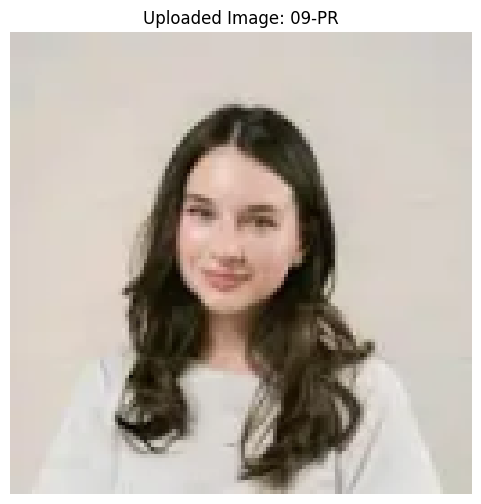

Image shape: (128, 128, 3)


In [9]:
import matplotlib.pyplot as plt
import cv2
import os

IMAGE_FILE_PATH = '/content/09-PR'
IMG_SIZE = (128, 128)

if os.path.exists(IMAGE_FILE_PATH):
    print(f"Loading and displaying image: {IMAGE_FILE_PATH}")
    try:
        image = cv2.imread(IMAGE_FILE_PATH)

        if image is None:
            print(f"Error: Could not read image from {IMAGE_FILE_PATH}. File might be corrupted or not a valid image format for OpenCV.")
        else:
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            resized_image = cv2.resize(image_rgb, IMG_SIZE)
            plt.figure(figsize=(6, 6))
            plt.imshow(resized_image)
            plt.title(f"Uploaded Image: {os.path.basename(IMAGE_FILE_PATH)}")
            plt.axis('off')
            plt.show()
            print(f"Image shape: {resized_image.shape}")

    except Exception as e:
        print(f"An error occurred while processing the image: {e}")
else:
    print(f"Error: Image file not found at {IMAGE_FILE_PATH}. Please ensure the file is uploaded correctly.")




In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(128,128,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)